In [33]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('/content/drive/MyDrive/data-scince-main/credit_score_dataset.csv') # Замените на ваш путь
target = 'Approved'

X = data.drop(columns=[target])
y = data[target].values

In [20]:
print("Форма данных:", data.shape)
print("Типы данных:\n", data.dtypes)
print("Первые 5 строк:\n", data.head())
print("Статистика числовых признаков:\n", data.describe())
print("Статистика категориальных признаков:\n", data.describe(include=['object', 'category', 'bool']))

Форма данных: (690, 18)
Типы данных:
 Gender               int64
Age                float64
Debt               float64
Married              int64
BankCustomer         int64
Industry            object
InvestmentScore    float64
BankRecord           int64
Ethnicity           object
YearsEmployed      float64
PriorDefault         int64
Employed             int64
CreditScore          int64
DriversLicense       int64
Citizen             object
ZipCode              int64
Income               int64
Approved             int64
dtype: object
Первые 5 строк:
    Gender    Age   Debt  Married  BankCustomer     Industry  InvestmentScore  \
0       1  30.83  0.000        1             1  Industrials             3.65   
1       0  58.67  4.460        1             1    Materials             1.94   
2       0  24.50  0.500        1             1    Materials             8.15   
3       1  27.83  1.540        1             1  Industrials             7.99   
4       1  20.17  5.625        1             

In [21]:
print("Пропуски по столбцам:\n", data.isnull().sum())

Пропуски по столбцам:
 Gender             0
Age                0
Debt               0
Married            0
BankCustomer       0
Industry           0
InvestmentScore    0
BankRecord         0
Ethnicity          0
YearsEmployed      0
PriorDefault       0
Employed           0
CreditScore        0
DriversLicense     0
Citizen            0
ZipCode            0
Income             0
Approved           0
dtype: int64


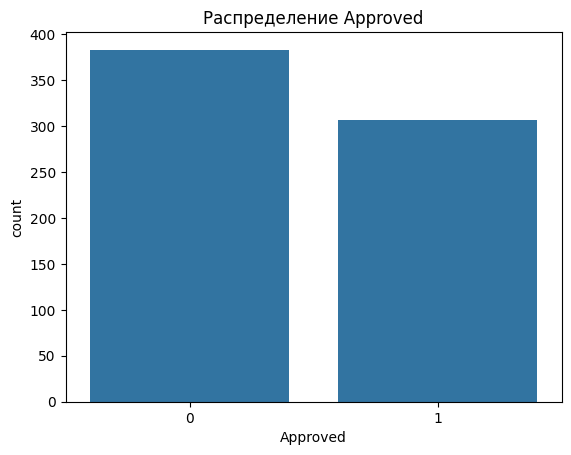

In [22]:
sns.countplot(x=target, data=data)
plt.title("Распределение Approved")
plt.show()

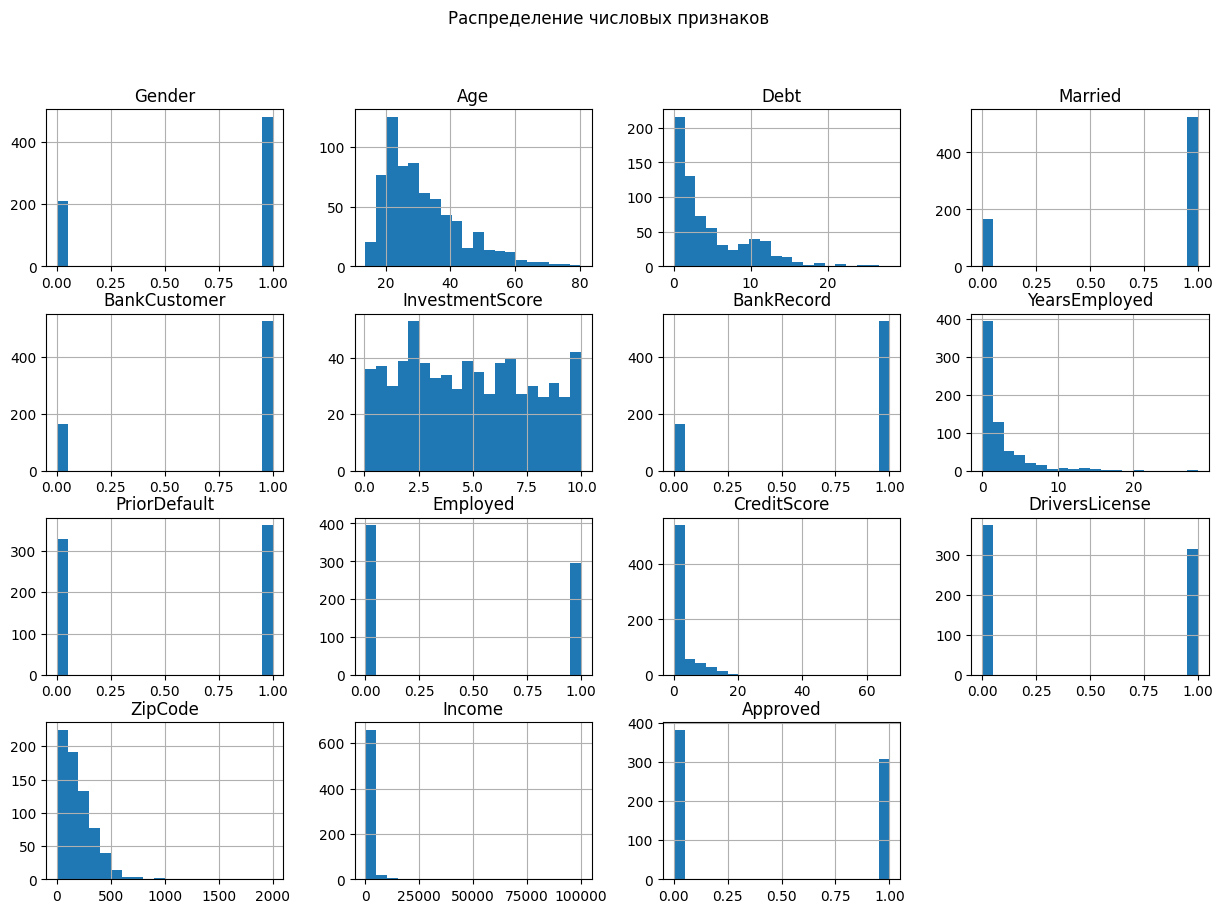

In [23]:
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
data[numerical_features].hist(bins=20, figsize=(15, 10))
plt.suptitle("Распределение числовых признаков")
plt.show()

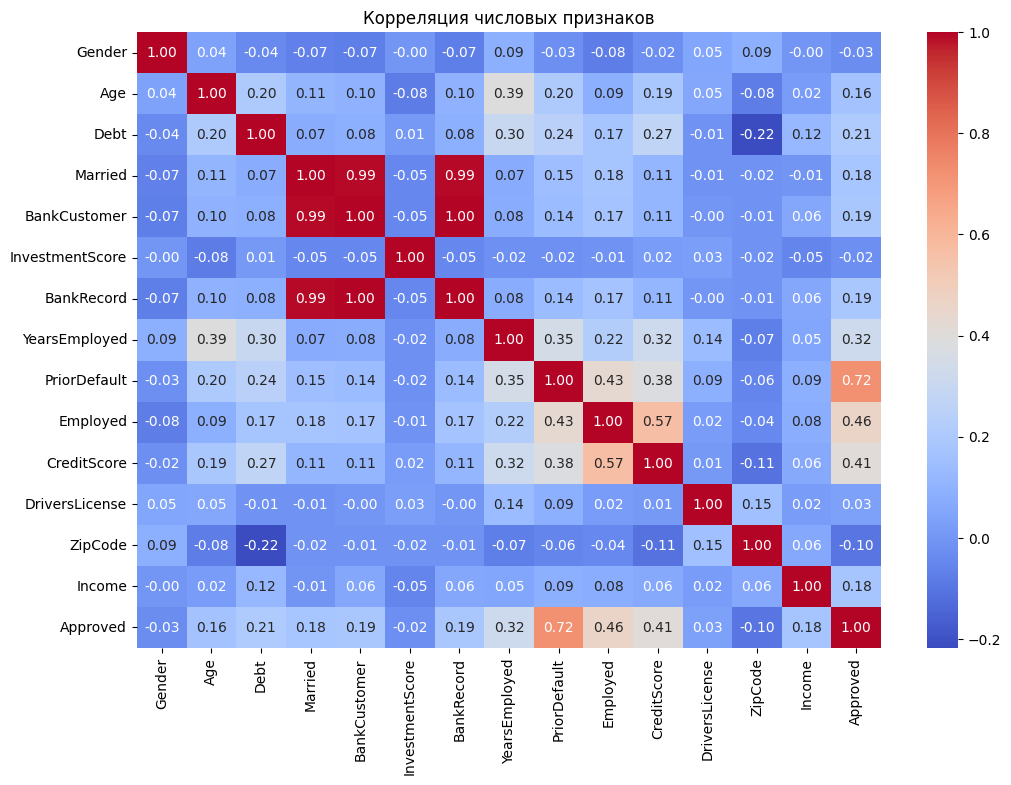

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция числовых признаков")
plt.show()

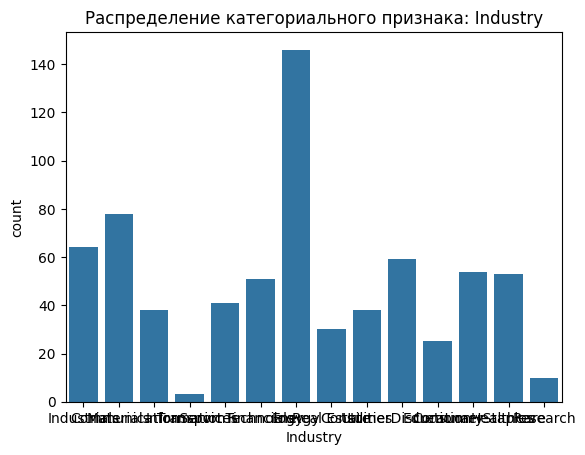

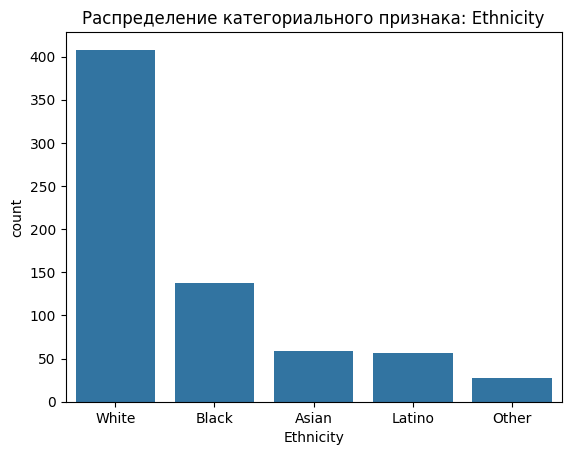

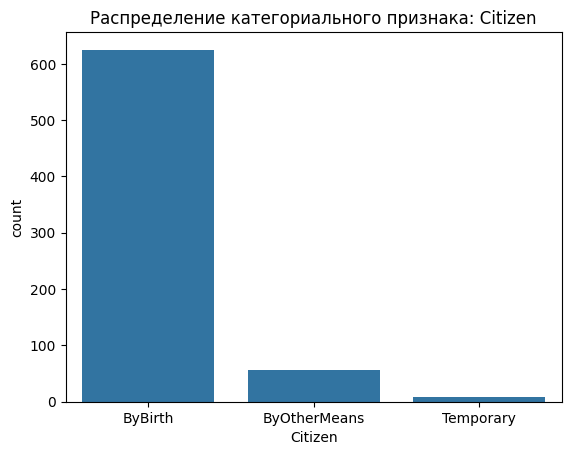

In [25]:
categorical_features = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
for col in categorical_features:
    sns.countplot(x=col, data=data)
    plt.title(f"Распределение категориального признака: {col}")
    plt.show()

In [28]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

scaler = MinMaxScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [29]:
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_features)

In [30]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

model.fit(train_pool, eval_set=test_pool)

In [35]:
y_proba = model.predict_proba(test_pool)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.9700850661625708


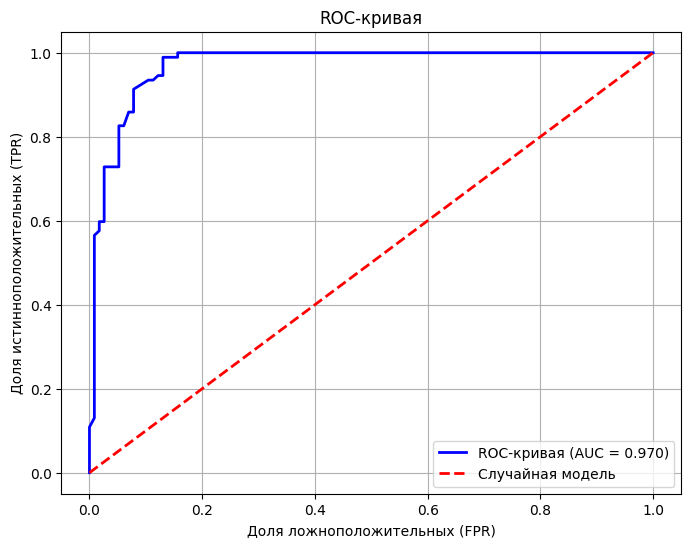

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Случайная модель')
plt.xlabel('Доля ложноположительных (FPR)')
plt.ylabel('Доля истинноположительных (TPR)')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()